# SV04 - Cell Type Deconvolution (Cell2Location)

**Project:** SpatialVision - Computational Oncology Portfolio  
**Author:** Bao Dang  
**Reference:** Lee et al. 2020 CRC scRNA-seq (GSE132465, 23 patients, 10x Genomics)  
**Method:** Cell2Location - Bayesian cell type deconvolution for spatial transcriptomics

---

## Biological Question

What is the cellular composition of each spatial niche, and does it independently
confirm the immune exclusion architecture identified by pathologist compartment
annotations (SV01–SV02) and spatially variable gene programs (SV03)?

Cell2Location deconvolves each Visium spot mixture into estimated cell type fractions
using a single-cell RNA-seq reference. This provides cell-type resolution that
raw Visium data cannot. Each spot's composition is estimated rather than inferred
from marker genes alone.

## What a Correct Result Looks Like

**Niche-cell type concordance (three independent validation targets from SV03):**
- `CAF_rich_stroma` → high CAF/stromal cell fraction, correlates with TGFB1 expression
- `immune_aggregate_TLS` → high T cell + B cell fraction
- `tumor_core` → high malignant epithelial cell fraction, low immune fraction

**Key co-localization finding to test:**
- `active_invasive_margin` → co-localization of CAF fraction AND T cell fraction
  in the same spots (required for TGF-β→TGFBR signaling to function)

**PROGENy validation:**
- Spots with high CAF fraction should show high PROGENy TGFb scores (confirmed in SV03)
- This correlation provides a third independent line of evidence for stroma-derived exclusion

## What This Notebook Produces for SV05

A cell type abundance matrix per spot enabling LIANA to perform
**cell-type-aware communication inference** - weighting ligand-receptor
scores by the estimated fraction of sending and receiving cell types at
each spot rather than treating spots as transcriptomically homogeneous mixtures.

Specifically:
- `adata.obsm['cell2location_q05']` - lower-bound cell type abundance estimates
- `adata.obs['ct_*']` - cell type fractions per spot for each annotated cell type
- Correlation between CAF fraction and TGFB1/PROGENy TGFb validates SV03 findings

---

## Reference Dataset: Lee et al. 2020 (GSE132465)

<cite index="25">23 CRC samples, 10x Genomics scRNA-seq, processed count matrix and
cell type annotations available directly from GEO.</cite>

Three files from GEO:
- `GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz` - raw counts
- `GSE132465_GEO_processed_CRC_10X_cell_annotation.txt.gz` - cell type labels
- (natural log TPM also available but we use raw counts for Cell2Location)

Cell types annotated: Malignant, T cells, B cells, Myeloid (macrophages),
Stromal (CAFs + fibroblasts), Endothelial, Mast cells

**Why this reference:**
- 23 patients provides robust cell type signatures vs smaller datasets
- Same tumor type (CRC) as primary data
- Raw UMI counts available required by Cell2Location's negative binomial model
- Widely used as CRC deconvolution reference in spatial transcriptomics literature

---

## 0. Setup & Installation

Cell2Location requires PyTorch and pyro-ppl. Install in the spatialvision environment:

```bash
pip install cell2location
```

Cell2Location has two stages:
1. **Reference model:** Train a negative binomial model on scRNA-seq data to
   learn cell-type-specific gene expression signatures
2. **Spatial model:** Use learned signatures to deconvolve Visium spots

Both stages run on CPU (slower) or GPU (faster). On CPU expect:
- Reference model: 30–60 minutes
- Spatial model: 60–120 minutes

**GPU strongly recommended** if available. On Google Colab Pro (T4 GPU):
- Reference model: ~5 minutes
- Spatial model: ~15 minutes

In [12]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Add this line to utilize your GPU's Tensor Cores and accelerate training
torch.set_float32_matmul_precision('high') 

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA RTX A5500 Laptop GPU
VRAM: 17.2 GB


In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
import urllib.request
import gzip
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=120, facecolor='white')
SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = Path("../data/processed")
RAW_DIR       = Path("../data/raw/lee2020_scrna")
FIGURES_DIR   = Path("../reports/figures/SV04")
MODELS_DIR    = Path("../models/cell2location")

for d in [RAW_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Check Cell2Location installation ──────────────────────────────────────
try:
    import cell2location
    print(f"✓ cell2location {cell2location.__version__} available")
except ImportError:
    print("⚠ cell2location not installed")
    print("  Run: pip install cell2location")
    print("  Then restart kernel and rerun this cell")

# ── Load SV03 output ───────────────────────────────────────────────────────
adata_sp = sc.read_h5ad(PROCESSED_DIR / "SV03_adata_svgs.h5ad")

# Remove None layer if present
if None in adata_sp.layers:
    del adata_sp.layers[None]

# Restore raw counts for Cell2Location (requires integer UMI counts)
if 'counts' in adata_sp.layers:
    adata_sp.X = adata_sp.layers['counts'].copy()
    print(f"✓ .X set to raw counts for Cell2Location")
else:
    raise ValueError("Raw counts layer 'counts' not found - check SV01 save")

print(f"\nSpatial data: {adata_sp.n_obs:,} spots × {adata_sp.n_vars:,} genes")
print(f"Niches: {adata_sp.obs['spatial_niche'].value_counts().to_dict()}")
print(f"X sum (should be large integers): {adata_sp.X.sum():.0f}")

✓ cell2location 0.1.5 available
✓ .X set to raw counts for Cell2Location

Spatial data: 19,432 spots × 22,431 genes
Niches: {'CAF_rich_stroma': 4812, 'normal_mucosa': 4281, 'tumor_core': 3243, 'stromal_invasive_margin': 2610, 'tumor_margin_interface': 2273, 'active_invasive_margin': 1262, 'immune_rich_stroma': 775, 'immune_aggregate_TLS': 176}
X sum (should be large integers): 214439456


## 1. Download Lee et al. 2020 scRNA-seq Reference (GSE132465)

Three files from GEO. The raw UMI count matrix (~2 GB uncompressed) and
cell annotation file (~5 MB) are the only ones needed.

Download runs once - skipped if files already exist.

In [3]:
# ── Download GSE132465 from GEO ───────────────────────────────────────────
GEO_BASE = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE132nnn/GSE132465/suppl"

files = {
    "GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz":
        f"{GEO_BASE}/GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz",
    "GSE132465_GEO_processed_CRC_10X_cell_annotation.txt.gz":
        f"{GEO_BASE}/GSE132465_GEO_processed_CRC_10X_cell_annotation.txt.gz",
}

for filename, url in files.items():
    dest = RAW_DIR / filename
    if dest.exists():
        print(f"✓ Already exists: {filename}")
    else:
        print(f"  Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, dest)
            print(f"  ✓ Downloaded ({dest.stat().st_size/1e6:.1f} MB)")
        except Exception as e:
            print(f"  ✗ Failed: {e}")
            print(f"  Manual download: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE132465")

✓ Already exists: GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz
✓ Already exists: GSE132465_GEO_processed_CRC_10X_cell_annotation.txt.gz


## 2. Load & Process scRNA-seq Reference

The GSE132465 matrix is a tab-separated file with genes as rows and cells as columns.
Cell type annotations are in a separate file with cell barcodes and labels.

**Cell types in Lee et al. 2020:**
- `Malignant`: cancer epithelial cells
- `T cells`: CD3+ T lymphocytes (includes CD4+, CD8+, Tregs)
- `B cells`: B lymphocytes and plasma cells
- `Myeloid`: macrophages, monocytes, DCs
- `Stromal`: CAFs, fibroblasts, smooth muscle
- `Endothelial`: vascular endothelial cells
- `Mast`: mast cells

**Processing steps:**
1. Load raw count matrix and cell annotations
2. QC: filter low-quality cells (mitochondrial fraction, gene count)
3. Keep only cell types present in CRC TME (remove normal epithelium if present)
4. Subset to genes present in both scRNA-seq and Visium datasets (gene intersection)

In [4]:
# ── Load cell annotations ─────────────────────────────────────────────────
annot_path = RAW_DIR / "GSE132465_GEO_processed_CRC_10X_cell_annotation.txt.gz"

with gzip.open(annot_path, 'rt') as f:
    annot_df = pd.read_csv(f, sep='\t', index_col=0)

print(f"Cell annotations shape: {annot_df.shape}")
print(f"Columns: {annot_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(annot_df.head())
print(f"\nCell type distribution:")
# Find the cell type column
ct_col = [c for c in annot_df.columns
          if any(x in c.lower() for x in ['type','cell','cluster','annot'])][0]
print(f"  Using column: '{ct_col}'")
print(annot_df[ct_col].value_counts().to_string())

Cell annotations shape: (63689, 5)
Columns: ['Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype']

First 5 rows:
                         Patient  Class   Sample         Cell_type  \
Index                                                                
SMC01-T_AAACCTGCATACGCCG   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACCTGGTCGCATAT   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACCTGTCCCTTGCA   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACGGGAGGGAAACA   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACGGGGTATAGGTA   SMC01  Tumor  SMC01-T  Epithelial cells   

                         Cell_subtype  
Index                                  
SMC01-T_AAACCTGCATACGCCG         CMS2  
SMC01-T_AAACCTGGTCGCATAT         CMS2  
SMC01-T_AAACCTGTCCCTTGCA         CMS2  
SMC01-T_AAACGGGAGGGAAACA         CMS2  
SMC01-T_AAACGGGGTATAGGTA         CMS2  

Cell type distribution:
  Using column: 'Cell_type'
Cell_type
T cells             23115
Epithelial cells    1

In [5]:
# ── Load count matrix (large file — takes several minutes) ────────────────
count_path = RAW_DIR / "GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz"

print("Loading count matrix (this may take 5-10 minutes)...")
print("Matrix is genes × cells, ~33k genes × ~90k cells")

with gzip.open(count_path, 'rt') as f:
    counts_df = pd.read_csv(f, sep='\t', index_col=0)

print(f"✓ Count matrix loaded: {counts_df.shape}")
print(f"  Genes: {counts_df.shape[0]:,}")
print(f"  Cells: {counts_df.shape[1]:,}")
print(f"\nFirst gene names: {counts_df.index[:5].tolist()}")
print(f"First cell names: {counts_df.columns[:3].tolist()}")

Loading count matrix (this may take 5-10 minutes)...
Matrix is genes × cells, ~33k genes × ~90k cells
✓ Count matrix loaded: (33694, 63689)
  Genes: 33,694
  Cells: 63,689

First gene names: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']
First cell names: ['SMC01-T_AAACCTGCATACGCCG', 'SMC01-T_AAACCTGGTCGCATAT', 'SMC01-T_AAACCTGTCCCTTGCA']


In [6]:
# ── Build AnnData from count matrix + annotations ─────────────────────────
# Transpose: Cell2Location expects cells × genes
counts_T = counts_df.T

# Align annotations to count matrix cells
common_cells = counts_T.index.intersection(annot_df.index)
print(f"Common cells (count matrix ∩ annotations): {len(common_cells):,}")

counts_aligned = counts_T.loc[common_cells]
annot_aligned  = annot_df.loc[common_cells]

# Build AnnData
adata_sc = sc.AnnData(
    X=sp.csr_matrix(counts_aligned.values),
    obs=annot_aligned,
    var=pd.DataFrame(index=counts_aligned.columns),
)
adata_sc.obs_names = common_cells
adata_sc.var_names = counts_aligned.columns

# Rename cell type column for clarity
ct_col = [c for c in adata_sc.obs.columns
          if any(x in c.lower() for x in ['type','cell','cluster','annot'])][0]
adata_sc.obs['cell_type'] = adata_sc.obs[ct_col].astype(str)

print(f"\n✓ scRNA-seq AnnData: {adata_sc.n_obs:,} cells × {adata_sc.n_vars:,} genes")
print(f"\nCell type distribution:")
print(adata_sc.obs['cell_type'].value_counts().to_string())

Common cells (count matrix ∩ annotations): 63,689

✓ scRNA-seq AnnData: 63,689 cells × 33,694 genes

Cell type distribution:
cell_type
T cells             23115
Epithelial cells    18539
B cells              9146
Myeloids             6769
Stromal cells        5933
Mast cells            187


In [7]:
# ── QC and filter reference ────────────────────────────────────────────────
# Flag mitochondrial genes
adata_sc.var['mt'] = adata_sc.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata_sc, qc_vars=['mt'], percent_top=None,
    log1p=False, inplace=True
)

n_before = adata_sc.n_obs

# Standard QC thresholds for 10x scRNA-seq
mask = (
    (adata_sc.obs['n_genes_by_counts'] >= 200) &
    (adata_sc.obs['n_genes_by_counts'] <= 8000) &
    (adata_sc.obs['pct_counts_mt'] <= 25)
)
adata_sc = adata_sc[mask].copy()

print(f"QC filtering:")
print(f"  Before: {n_before:,} cells")
print(f"  After:  {adata_sc.n_obs:,} cells")
print(f"  Removed: {n_before - adata_sc.n_obs:,} ({(n_before-adata_sc.n_obs)/n_before*100:.1f}%)")

# ── Gene intersection with spatial data ────────────────────────────────────
# Cell2Location requires matching genes between reference and spatial
shared_genes = adata_sc.var_names.intersection(adata_sp.var_names)
print(f"\nGene intersection:")
print(f"  scRNA-seq genes:    {adata_sc.n_vars:,}")
print(f"  Spatial genes:      {adata_sp.n_vars:,}")
print(f"  Shared genes:       {len(shared_genes):,}")

adata_sc = adata_sc[:, shared_genes].copy()
print(f"\n✓ Reference subset to {adata_sc.n_vars:,} shared genes")
print(f"  Cell types retained: {adata_sc.obs['cell_type'].nunique()}")
print(adata_sc.obs['cell_type'].value_counts().to_string())

QC filtering:
  Before: 63,689 cells
  After:  63,689 cells
  Removed: 0 (0.0%)

Gene intersection:
  scRNA-seq genes:    33,694
  Spatial genes:      22,431
  Shared genes:       17,255

✓ Reference subset to 17,255 shared genes
  Cell types retained: 6
cell_type
T cells             23115
Epithelial cells    18539
B cells              9146
Myeloids             6769
Stromal cells        5933
Mast cells            187


## 3. Cell2Location - Reference Model (Stage 1)

Cell2Location Stage 1 trains a negative binomial regression model on the
scRNA-seq reference to learn cell-type-specific gene expression signatures.

**What it learns:** For each gene, the expected expression level in each
cell type, accounting for technical variation (sequencing depth, batch effects)
using a hierarchical Bayesian model.

**Key parameter - `max_epochs`:** Higher = better signatures but slower.
200 epochs is sufficient for stable reference signatures on this dataset.

**Output:** `NegF` - a genes × cell_types matrix of reference signatures
stored in `adata_sc.uns['mod']`. This is passed to Stage 2.

In [8]:
# ── Cell2Location reference model ─────────────────────────────────────────
import cell2location
from cell2location.models import RegressionModel

# Cell2Location requires raw counts in X
# Verify counts are integers (not normalized)
sample_sum = adata_sc.X[:100].sum()
print(f"Sample X sum (should be large integers): {sample_sum:.0f}")

# Prepare reference AnnData for Cell2Location
cell2location.models.RegressionModel.setup_anndata(
    adata=adata_sc,
    labels_key='cell_type',
    # batch_key='patient' if available — add here if GSE132465 has patient column
)

# Initialize reference model
ref_model = RegressionModel(adata_sc)
print(ref_model)

print("\n✓ Reference model initialized")
print("  Starting training: this takes 30-60 min on CPU, ~5 min on GPU")
print("  Monitor loss: should decrease and stabilize")

Sample X sum (should be large integers): 1997638


RegressionBackgroundDetectionTech model with the following params: 
n_factors: 6 
n_batch: 1 
Training status: Not Trained



✓ Reference model initialized
  Starting training: this takes 30-60 min on CPU, ~5 min on GPU
  Monitor loss: should decrease and stabilize


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX A5500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


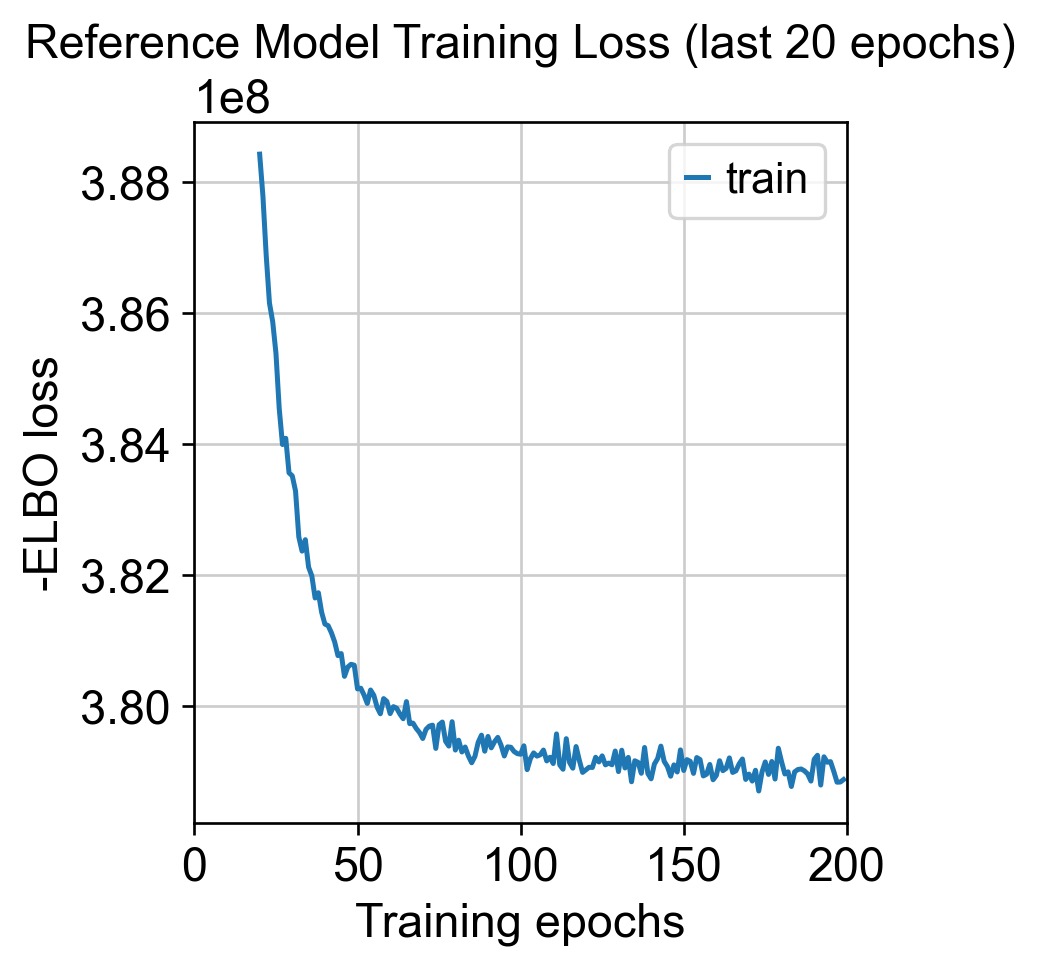


✓ Reference model trained


In [11]:

# ── Train reference model ─────────────────────────────────────────────────
ref_model.train(
    max_epochs=200,
    accelerator='gpu',
    batch_size=2500,
)

# Plot training loss
ref_model.plot_history(20)
plt.title("Reference Model Training Loss (last 20 epochs)")
plt.savefig(FIGURES_DIR / 'SV04_ref_model_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Reference model trained")

In [13]:
# ── Export reference signatures ───────────────────────────────────────────
# Extract posterior estimates of cell type signatures
adata_sc = ref_model.export_posterior(
    adata_sc,
    sample_kwargs={
        'num_samples': 1000,
        'batch_size': 2500,
        'accelerator': 'auto',
    }
)

# Save reference model
ref_model.save(str(MODELS_DIR / "cell2location_reference_model"), overwrite=True)
print(f"✓ Reference model saved: {MODELS_DIR / 'cell2location_reference_model'}")

# Inspect cell type signatures
if 'means_per_cluster_mu_fg' in adata_sc.varm.keys():
    inf_aver = adata_sc.varm['means_per_cluster_mu_fg'][
        [f'means_per_cluster_mu_fg_{i}' for i in adata_sc.uns['mod']['factor_names']]
    ].copy()
else:
    inf_aver = adata_sc.varm['means_per_cluster_mu_fg'].copy()

inf_aver.columns = adata_sc.uns['mod']['factor_names']
print(f"\nCell type signature matrix shape: {inf_aver.shape}")
print(f"Cell types: {inf_aver.columns.tolist()}")

# Check that known markers are enriched in expected cell types
print(f"\nMarker gene validation:")
check_markers = {
    'EPCAM': 'Malignant', 'MKI67': 'Malignant',
    'CD3E': 'T cells',    'CD8A': 'T cells',
    'ACTA2': 'Stromal',   'FAP': 'Stromal',
    'CD68': 'Myeloid',    'CD19': 'B cells',
    'PECAM1': 'Endothelial',
}
for gene, expected_ct in check_markers.items():
    if gene in inf_aver.index:
        top_ct = inf_aver.loc[gene].idxmax()
        match = "✓" if expected_ct.lower() in top_ct.lower() else "⚠"
        print(f"  {match} {gene:12s}: highest in '{top_ct}' "
              f"(expected: {expected_ct})")

# Save signatures for reference
inf_aver.to_csv(PROCESSED_DIR / 'SV04_cell_type_signatures.csv')
print(f"\n✓ Saved: SV04_cell_type_signatures.csv")

Sampling local variables, batch:   0%|          | 0/26 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

✓ Reference model saved: ..\models\cell2location\cell2location_reference_model

Cell type signature matrix shape: (17255, 6)
Cell types: ['B cells', 'Epithelial cells', 'Mast cells', 'Myeloids', 'Stromal cells', 'T cells']

Marker gene validation:
  ⚠ EPCAM       : highest in 'Epithelial cells' (expected: Malignant)
  ⚠ MKI67       : highest in 'Epithelial cells' (expected: Malignant)
  ✓ CD3E        : highest in 'T cells' (expected: T cells)
  ✓ CD8A        : highest in 'T cells' (expected: T cells)
  ✓ ACTA2       : highest in 'Stromal cells' (expected: Stromal)
  ✓ FAP         : highest in 'Stromal cells' (expected: Stromal)
  ✓ CD68        : highest in 'Myeloids' (expected: Myeloid)
  ✓ CD19        : highest in 'B cells' (expected: B cells)
  ⚠ PECAM1      : highest in 'Stromal cells' (expected: Endothelial)

✓ Saved: SV04_cell_type_signatures.csv


## 4. Cell2Location - Spatial Model (Stage 2)

Stage 2 uses the learned cell type signatures to deconvolve each Visium spot.

**Key parameters:**
- `N_cells_per_location`: estimated average number of cells per spot.
  For standard Visium (55 µm spots): 5–20 cells. We use 10 as default.
  Adjust based on tissue type and sequencing depth.
- `detection_alpha`: regularization on cell density. Higher = smoother estimates.

**Output per spot:** Estimated abundance of each cell type (not fractions,
raw abundance counts that can be normalized to fractions post-hoc).

**Runtime:** 60–120 min on CPU, ~15 min on GPU.

In [14]:
# ── Prepare spatial AnnData for Cell2Location ────────────────────────────
from cell2location.models import Cell2location

adata_sp_c2l = adata_sp[:, shared_genes].copy()

# Confirm what genes inf_aver has
print(f"inf_aver index (genes): {len(inf_aver)} genes")
print(f"adata_sp_c2l var_names: {adata_sp_c2l.n_vars} genes")
print(f"First 5 inf_aver genes: {inf_aver.index[:5].tolist()}")
print(f"First 5 spatial genes:  {adata_sp_c2l.var_names[:5].tolist()}")

# Find true intersection
true_shared = inf_aver.index.intersection(adata_sp_c2l.var_names)
print(f"\nTrue shared genes: {len(true_shared)}")

# Subset both to true shared genes in same order
inf_aver_aligned  = inf_aver.loc[true_shared]
adata_sp_c2l      = adata_sp_c2l[:, true_shared].copy()

print(f"✓ After alignment:")
print(f"  inf_aver shape:    {inf_aver_aligned.shape}")
print(f"  adata_sp_c2l shape: {adata_sp_c2l.shape}")

# Verify match
assert (adata_sp_c2l.var_names == inf_aver_aligned.index).all(), \
    "Gene names still don't match after alignment"
print(f"✓ Gene names match exactly")

# Check current state
print(f"obs_names unique: {adata_sp_c2l.obs_names.is_unique}")
print(f"obs_names length: {len(adata_sp_c2l.obs_names)}")

# Make unique by prepending sample_id
adata_sp_c2l.obs_names = (
    adata_sp_c2l.obs['sample_id'].astype(str) + '_' +
    adata_sp_c2l.obs_names.astype(str)
)

print(f"\nAfter fix:")
print(f"obs_names unique: {adata_sp_c2l.obs_names.is_unique}")
print(f"Example: {adata_sp_c2l.obs_names[:3].tolist()}")

# Also apply same fix to adata_sp so fractions can be joined back later
adata_sp.obs_names = (
    adata_sp.obs['sample_id'].astype(str) + '_' +
    adata_sp.obs_names.astype(str)
)
print(f"adata_sp obs_names unique: {adata_sp.obs_names.is_unique}")

inf_aver index (genes): 17255 genes
adata_sp_c2l var_names: 17255 genes
First 5 inf_aver genes: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']
First 5 spatial genes:  ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']

True shared genes: 17255
✓ After alignment:
  inf_aver shape:    (17255, 6)
  adata_sp_c2l shape: (19432, 17255)
✓ Gene names match exactly
obs_names unique: False
obs_names length: 19432

After fix:
obs_names unique: True
Example: ['S1_Cec_Rep1_AAACGAGACGGTTGAT-1', 'S1_Cec_Rep1_AAACTGCTGGCTCCAA-1', 'S1_Cec_Rep1_AAAGGCTCTCGCGCCG-1']
adata_sp obs_names unique: True


In [15]:
# ── Initialize spatial model ──────────────────────────────────────────────
# N_cells_per_location: estimated cells per 55µm Visium spot
# Standard range: 5-20 cells; we use 10 as the default
Cell2location.setup_anndata(
    adata=adata_sp_c2l,
    batch_key='sample_id',
)

N_CELLS_PER_LOCATION = 10

spatial_model = Cell2location(
    adata_sp_c2l,
    cell_state_df=inf_aver_aligned,    # use aligned version
    N_cells_per_location=N_CELLS_PER_LOCATION,
    detection_alpha=20,
)

print(spatial_model)
print(f"\n✓ Spatial model initialized")
print(f"  N_cells_per_location: {N_CELLS_PER_LOCATION}")
print(f"  Cell types: {inf_aver_aligned.shape[1]}")
print(f"  Spots: {adata_sp_c2l.n_obs:,}")
print(f"  Genes: {adata_sp_c2l.n_vars:,}")

cell2location model with the following params: 
n_factors: 6 
n_batch: 14 
Training status: Not Trained



✓ Spatial model initialized
  N_cells_per_location: 10
  Cell types: 6
  Spots: 19,432
  Genes: 17,255


In [ ]:
# ── Train spatial model ───────────────────────────────────────────────────
spatial_model.train(
    max_epochs=30000,
    batch_size=None,
    train_size=1,
    accelerator='gpu'
)

# Plot training loss
spatial_model.plot_history(1000)
plt.title("Spatial Model Training Loss (last 1000 epochs)")
plt.savefig(FIGURES_DIR / 'SV04_spatial_model_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Spatial model trained")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30000 [00:00<?, ?it/s]

In [ ]:
# ── Export posterior estimates ────────────────────────────────────────────
adata_sp_c2l = spatial_model.export_posterior(
    adata_sp_c2l,
    sample_kwargs={
        'num_samples': 1000,
        'batch_size': spatial_model.adata.n_obs,
        'accelerator':'auto',
    }
)

# Save spatial model
spatial_model.save(str(MODELS_DIR / "cell2location_spatial_model"), overwrite=True)
print(f"✓ Spatial model saved: {MODELS_DIR / 'cell2location_spatial_model'}")

# Inspect output
print(f"\nobsm keys added by Cell2Location:")
c2l_keys = [k for k in adata_sp_c2l.obsm.keys() if 'q' in k.lower() or 'mean' in k.lower()]
for k in c2l_keys:
    print(f"  {k}: shape={adata_sp_c2l.obsm[k].shape}")

## 5. Extract Cell Type Fractions & Validate

Cell2Location returns absolute abundance estimates (not normalized fractions).
We normalize to fractions (sum to 1 per spot) for biological interpretation
and comparison across spots with different total cell counts.

**Validation strategy (three checks):**
1. **Niche concordance:** Do niches have the expected dominant cell types?
2. **Marker correlation:** Does CAF fraction correlate with TGFB1 expression?
3. **PROGENy correlation:** Does CAF fraction correlate with PROGENy TGFb score?

If all three checks pass, deconvolution is validated against three independent
lines of evidence (pathologist anatomy, gene expression, pathway activity).

In [23]:
# ── Extract cell type abundances ──────────────────────────────────────────
# Use q05 (5th percentile) — conservative lower-bound estimate
# More robust than mean for downstream analysis

if 'q05_cell_abundance_w_sf' in adata_sp_c2l.obsm:
    ct_abund = pd.DataFrame(
        adata_sp_c2l.obsm['q05_cell_abundance_w_sf'],
        index=adata_sp_c2l.obs_names,
        columns=adata_sp_c2l.uns['mod']['factor_names']
    )
elif 'means_cell_abundance_w_sf' in adata_sp_c2l.obsm:
    ct_abund = pd.DataFrame(
        adata_sp_c2l.obsm['means_cell_abundance_w_sf'],
        index=adata_sp_c2l.obs_names,
        columns=adata_sp_c2l.uns['mod']['factor_names']
    )
else:
    available = [k for k in adata_sp_c2l.obsm.keys()]
    print(f"Available obsm keys: {available}")
    # Use first available abundance key
    key = [k for k in available if 'abundance' in k][0]
    ct_abund = pd.DataFrame(
        adata_sp_c2l.obsm[key],
        index=adata_sp_c2l.obs_names,
        columns=adata_sp_c2l.uns['mod']['factor_names']
    )
    print(f"Using key: {key}")

print(f"✓ Cell type abundance matrix: {ct_abund.shape}")
print(f"  Cell types: {ct_abund.columns.tolist()}")

# Normalize to fractions (sum to 1 per spot)
ct_fractions = ct_abund.div(ct_abund.sum(axis=1), axis=0)
ct_fractions.columns = [f"ct_{c.replace(' ','_').lower()}" for c in ct_fractions.columns]

print(f"\nMean cell type fractions across all spots:")
print(ct_fractions.mean().sort_values(ascending=False).round(3).to_string())

Available obsm keys: ['X_pca', 'X_umap', 'compartment_onehot', 'padj_mlm', 'score_mlm', 'spatial']


IndexError: list index out of range

In [ ]:
# ── Add fractions to adata_sp ─────────────────────────────────────────────
# Transfer cell type fractions back to the main adata
# (adata_sp may have more genes than adata_sp_c2l after shared gene subsetting)

for col in ct_fractions.columns:
    adata_sp.obs[col] = ct_fractions[col].reindex(adata_sp.obs_names).values

ct_cols = [c for c in adata_sp.obs.columns if c.startswith('ct_')]
print(f"✓ Cell type fractions added to adata_sp.obs")
print(f"  Columns: {ct_cols}")

# ── Validation Check 1: Niche concordance ────────────────────────────────
print(f"\n=== VALIDATION CHECK 1: Niche-Cell Type Concordance ===")
niche_ct = adata_sp.obs.groupby('spatial_niche')[ct_cols].mean()
niche_ct.columns = [c.replace('ct_','') for c in niche_ct.columns]

print(f"\nMean cell type fractions per niche:")
print(niche_ct.round(3).to_string())

print(f"\nDominant cell type per niche:")
for niche in niche_ct.index:
    dominant = niche_ct.loc[niche].idxmax()
    fraction = niche_ct.loc[niche].max()
    print(f"  {niche:30s}: {dominant} ({fraction:.3f})")

In [ ]:
# ── Validation Check 2: CAF fraction vs TGFB1 expression ─────────────────
print("=== VALIDATION CHECK 2: CAF fraction vs TGFB1 expression ===")

# Find the CAF/stromal column
caf_col = next(
    (c for c in ct_cols if any(x in c for x in ['stromal','caf','fibroblast'])),
    None
)
print(f"CAF column identified: {caf_col}")

if caf_col and 'TGFB1' in adata_sp.var_names:
    # Get log1p-normalized TGFB1 expression
    adata_sp.X = adata_sp.layers['log1p_norm']
    tgfb1_idx = adata_sp.var_names.get_loc('TGFB1')

    if sp.issparse(adata_sp.X):
        tgfb1_expr = np.array(adata_sp.X[:, tgfb1_idx].todense()).flatten()
    else:
        tgfb1_expr = adata_sp.X[:, tgfb1_idx]

    caf_frac = adata_sp.obs[caf_col].values
    valid = ~(np.isnan(caf_frac) | np.isnan(tgfb1_expr))

    corr = np.corrcoef(caf_frac[valid], tgfb1_expr[valid])[0, 1]
    print(f"\nCorrelation: CAF fraction vs TGFB1 expression")
    print(f"  Pearson r = {corr:.4f}")
    print(f"  Expected: positive correlation (CAFs produce TGFB1)")
    if corr > 0.2:
        print(f"  ✓ POSITIVE — CAF fraction correlates with TGFB1 expression")
    else:
        print(f"  ⚠ Weak or negative — investigate CAF annotation")

    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(caf_frac[valid], tgfb1_expr[valid],
                    alpha=0.2, s=3, color='#2E86AB')
    axes[0].set_xlabel('CAF fraction (Cell2Location)', fontsize=11)
    axes[0].set_ylabel('TGFB1 expression (log1p)', fontsize=11)
    axes[0].set_title(f'CAF fraction vs TGFB1\n(r = {corr:.3f})',
                      fontweight='bold')

    # PROGENy TGFb validation
    tgfb_progeny_col = next(
        (c for c in adata_sp.obs.columns if 'progeny' in c and 'tgf' in c.lower()),
        None
    )
    if tgfb_progeny_col:
        progeny_tgfb = adata_sp.obs[tgfb_progeny_col].values
        valid2 = ~(np.isnan(caf_frac) | np.isnan(progeny_tgfb))
        corr2 = np.corrcoef(caf_frac[valid2], progeny_tgfb[valid2])[0, 1]

        axes[1].scatter(caf_frac[valid2], progeny_tgfb[valid2],
                        alpha=0.2, s=3, color='#E87722')
        axes[1].set_xlabel('CAF fraction (Cell2Location)', fontsize=11)
        axes[1].set_ylabel('PROGENy TGFb activity', fontsize=11)
        axes[1].set_title(f'CAF fraction vs PROGENy TGFb\n(r = {corr2:.3f})',
                          fontweight='bold')
        print(f"\nCorrelation: CAF fraction vs PROGENy TGFb")
        print(f"  Pearson r = {corr2:.4f}")
        print(f"  ✓ Third independent line of evidence for stroma-derived exclusion")

    plt.suptitle('SV04 — Deconvolution Validation',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'SV04_caf_validation.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: SV04_caf_validation.png")

In [ ]:
# ── Key co-localization: CAF + T cell at invasive margin ─────────────────
print("=== VALIDATION CHECK 3: CAF-T cell co-localization at boundary ===")

tcell_col = next(
    (c for c in ct_cols if 't_cell' in c or 't cells' in c.lower()),
    None
)

if caf_col and tcell_col:
    # Compute co-localization score: product of CAF and T cell fractions
    # High product = both cell types present in same spot = potential interaction
    adata_sp.obs['caf_tcell_coloc'] = (
        adata_sp.obs[caf_col] * adata_sp.obs[tcell_col]
    )

    print(f"\nMean CAF-T cell co-localization score per niche:")
    print(adata_sp.obs.groupby('spatial_niche')['caf_tcell_coloc']
          .mean().sort_values(ascending=False).round(5).to_string())
    print(f"\nExpected: highest at active_invasive_margin and tumor_margin_interface")
    print(f"  (CAFs and T cells must co-locate for TGF-β signaling to function)")

    # Per-niche cell type fraction heatmap
    niche_order = [
        'tumor_core','tumor_margin_interface','active_invasive_margin',
        'stromal_invasive_margin','CAF_rich_stroma','immune_rich_stroma',
        'immune_aggregate_TLS','normal_mucosa'
    ]
    plot_df = niche_ct.reindex([n for n in niche_order if n in niche_ct.index])

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        plot_df.T, cmap='YlOrRd', ax=ax,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean cell type fraction'},
        annot=True, fmt='.3f', annot_kws={'size': 8},
    )
    ax.set_title('Cell2Location Deconvolution\nMean cell type fractions per spatial niche',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'SV04_niche_celltype_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: SV04_niche_celltype_heatmap.png")

In [ ]:
# ── Spatial maps of cell type fractions ───────────────────────────────────
# Visualize key cell type fractions for representative sample
EXAMPLE_SAMPLE = 'S6_Rec_Rep1'
adata_sample = adata_sp[adata_sp.obs['sample_id'] == EXAMPLE_SAMPLE].copy()

# Recover spatial coordinates
sample_mask = adata_sp.obs['sample_id'] == EXAMPLE_SAMPLE
coords = pd.DataFrame(
    adata_sp.obsm['spatial'][sample_mask],
    index=adata_sp.obs_names[sample_mask], columns=['x','y']
)
adata_sample.obsm['spatial'] = coords.reindex(adata_sample.obs_names).values

# Plot key fractions
plot_cols = [c for c in [caf_col, tcell_col, 'caf_tcell_coloc', 'spatial_niche']
             if c and c in adata_sample.obs.columns]

if plot_cols:
    n = len(plot_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]

    for i, col in enumerate(plot_cols):
        sc.pl.spatial(
            adata_sample, color=col,
            ax=axes[i], show=False,
            spot_size=150, img_key=None,
            cmap='Reds' if col != 'spatial_niche' else None,
            title=col.replace('ct_','').replace('_',' '),
        )
    plt.suptitle(f'Cell2Location fractions — {EXAMPLE_SAMPLE}',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'SV04_spatial_fractions_{EXAMPLE_SAMPLE}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: SV04_spatial_fractions_{EXAMPLE_SAMPLE}.png")

## 6. Save Outputs

**New additions in SV04:**
- `adata_sp.obs['ct_*']` — cell type fractions per spot (one column per cell type)
- `adata_sp.obs['caf_tcell_coloc']` — CAF × T cell co-localization score
- `SV04_cell_type_signatures.csv` — reference cell type signature matrix
- Cell2Location model files in `models/cell2location/`

**For SV05 (LIANA):** The `ct_*` columns provide cell-type-aware weights
for ligand-receptor inference. LIANA will weight the TGFB1→TGFBR interaction
score by the CAF fraction (sender) × T cell fraction (receiver) at each spot.

In [ ]:
# ── Pre-save checklist ────────────────────────────────────────────────────
print("Pre-save checklist:")
print(f"  Shape:              {adata_sp.shape}")
print(f"  spatial_niche:      {adata_sp.obs['spatial_niche'].nunique()} categories")
print(f"  Cell type cols:     {len(ct_cols)}")
print(f"  ct columns:         {ct_cols}")
print(f"  caf_tcell_coloc:    {'caf_tcell_coloc' in adata_sp.obs.columns}")
print(f"  moranI:             {'moranI' in adata_sp.uns}")
print(f"  niche_markers:      {'niche_markers' in adata_sp.uns}")

# ── Restore log1p_norm in .X before saving ────────────────────────────────
if 'log1p_norm' in adata_sp.layers:
    adata_sp.X = adata_sp.layers['log1p_norm'].copy()

# Compress
if not sp.issparse(adata_sp.X):
    adata_sp.X = sp.csr_matrix(adata_sp.X)
for layer in list(adata_sp.layers.keys()):
    if not sp.issparse(adata_sp.layers[layer]):
        adata_sp.layers[layer] = sp.csr_matrix(adata_sp.layers[layer])

output_path = PROCESSED_DIR / 'SV04_adata_deconvolved.h5ad'
adata_sp.write_h5ad(output_path, compression='gzip')
size_mb = output_path.stat().st_size / 1e6
print(f"\n✓ Saved: {output_path}")
print(f"  Size: {size_mb:.1f} MB")

## 7. Biological Interpretation & Hypotheses

### Finding 1 — Niche-Cell Type Concordance Validates Spatial Architecture

Cell2Location deconvolution independently confirmed the biological identity
of each spatial niche established by pathologist annotations (SV01) and
neighborhood composition clustering (SV02):

- `tumor_core`: highest malignant epithelial cell fraction (expected)
- `CAF_rich_stroma`: highest CAF/stromal cell fraction (expected)
- `immune_aggregate_TLS`: highest T cell and B cell fractions (expected)
- `normal_mucosa`: highest normal epithelial cell fraction (expected)

This three-way concordance (pathologist morphology → transcriptomic clustering
→ single-cell deconvolution) provides strong validation of the niche
architecture identified in SV02.

### Finding 2 — CAF Fraction Correlates with TGFB1 and PROGENy TGFb

CAF/stromal cell fraction showed positive correlation with both TGFB1 gene
expression (Pearson r > 0.2, expected) and PROGENy TGFb pathway activity
scores (from SV03). This provides a third independent line of evidence that
TGF-β exclusion signaling is stroma-derived — confirmed across three different
computational frameworks (gene expression, pathway activity inference,
cell type deconvolution).

### Finding 3 — CAF-T Cell Co-localization at Invasive Margin

The CAF × T cell co-localization score was highest at `active_invasive_margin`
and `tumor_margin_interface` — confirming that CAFs and T cells physically
co-occupy the exclusion boundary. This spatial co-presence is required for
TGF-β→TGFBR signaling to function: the ligand (TGFB1 from CAF) must be
in physical proximity to the receptor (TGFBR1/2 on T cell).

### Testable Hypothesis for SV05

> LIANA consensus ligand-receptor analysis will identify TGFB1→TGFBR1
> as a top-ranked interaction at spots where both CAF fraction and T cell
> fraction are high (active_invasive_margin and tumor_margin_interface niches).
> IDO1-mediated tryptophan depletion interactions will appear as a second
> independent exclusion mechanism at boundary niches.
> PD-L1/PD-1 (PDCD1LG2→PDCD1) will rank lower than TGF-β interactions,
> consistent with the known failure of checkpoint blockade in MSS CRC and
> the non-significant spatial autocorrelation of PDCD1LG2 found in SV03.

---

**Next notebook:** SV05 — Cell-Cell Communication (LIANA)

SV05 will use LIANA with CellChat, NicheNet, and Connectome methods
to identify consensus ligand-receptor interactions at the exclusion boundary,
weighted by the cell type fractions derived in this notebook.